**In this case-study, the objective is to show that the S&P 500 prices from index2026.csv file is Non-stationary and the models won't be able to forecast the future prices. This we will conclude by plotting ACF plot and check the Autocorrelation b/w the prices and their lagged versions.**

`Then we will convert the prices into log returns and then again plot the autocorrelation function and conclude that the log returns are Stationary and the models can be applied to predict the future log returns!!`

In [16]:
# Importing the required modules
import pandas as pd
import numpy as np
import statsmodels.graphics.tsaplots as sgt
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('index2026.csv') #Importing the required data!

In [4]:
df.head()

,Ticker,spx,dax,ftse,nikkei
0,Price,NaN,NaN,NaN,NaN
1,Date,NaN,NaN,NaN,NaN
2,1994-01-10,475.269989,2225.000000,3440.600098,18443.439453
3,1994-01-11,474.130005,2228.100098,3413.800049,18485.250000
4,1994-01-12,474.170013,2182.060059,3372.000000,18793.880859


### We will pre process and clean the data for our requirements


In [6]:
df = df.iloc[2:]
df.Ticker = pd.to_datetime(df.Ticker)
df.set_index('Ticker',inplace=True)


In [7]:
df.head()

,spx,dax,ftse,nikkei
Ticker,,,,
1994-01-12,474.170013,2182.060059,3372.000000,18793.880859
1994-01-13,472.470001,2142.370117,3360.000000,18577.259766
1994-01-14,474.910004,2151.050049,3400.600098,18973.699219
1994-01-17,473.299988,2115.560059,3407.800049,18725.369141
1994-01-18,474.250000,2130.350098,3437.000000,18514.550781


In [8]:
df.index.name='Date'

In [9]:
df.head()

,spx,dax,ftse,nikkei
Date,,,,
1994-01-12,474.170013,2182.060059,3372.000000,18793.880859
1994-01-13,472.470001,2142.370117,3360.000000,18577.259766
1994-01-14,474.910004,2151.050049,3400.600098,18973.699219
1994-01-17,473.299988,2115.560059,3407.800049,18725.369141
1994-01-18,474.250000,2130.350098,3437.000000,18514.550781


In [ ]:
df['prices'] = df['spx']
del df['spx'], df['dax'], df['ftse'], df['nikkei'] # Removing unnecessary columns

In [13]:
df.head()

,prices
Date,
1994-01-12,474.170013
1994-01-13,472.470001
1994-01-14,474.910004
1994-01-17,473.299988
1994-01-18,474.250000


In [14]:
# Now we will make a column for log returns 
df['log_returns'] = np.log(df.prices/df.prices.shift(1))

In [15]:
df.head(10)

,prices,log_returns
Date,,
1994-01-12,474.170013,NaN
1994-01-13,472.470001,-0.003592
1994-01-14,474.910004,0.005151
1994-01-17,473.299988,-0.003396
1994-01-18,474.250000,0.002005
1994-01-19,474.299988,0.000105
1994-01-20,474.980011,0.001433
1994-01-21,474.720001,-0.000548
1994-01-24,471.970001,-0.005810


`Plotting Autocorrelation Function on S&P500 Raw Prices`

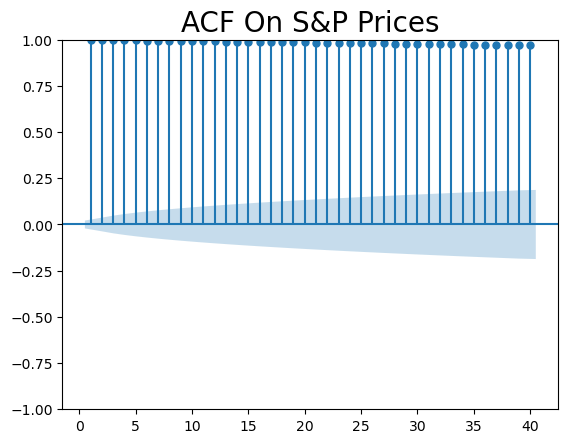

In [17]:
sgt.plot_acf(df.prices,lags=40,zero=False)
plt.title('ACF On S&P Prices',size=20)
plt.show()

`Plotting Autocorrelation Function on Log Returns of S&P500`

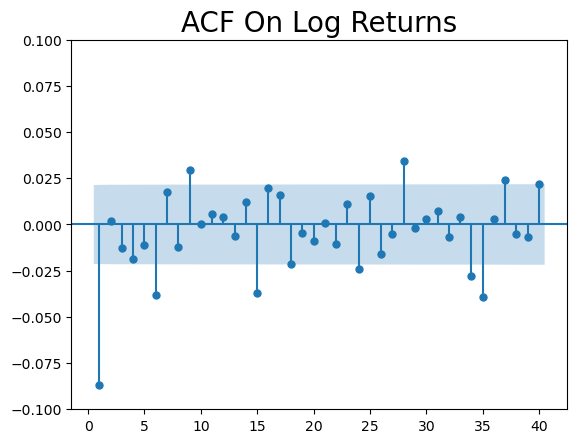

In [20]:
sgt.plot_acf(df.log_returns[1:],zero=False,lags=40) #we remove the first row since it has NAN value as return!
plt.title('ACF On Log Returns', size=20)
plt.ylim(-.1,.1)
plt.show()

`ACF Of lof returns is well inside the confidence band suggesting that the data is Stationary`

### Takeaway ->

### 1. Raw prices are unsuitable for forecasting directly
#### The ACF on S&P 500 prices will show very high autocorrelations across all 40 lags, decaying extremely slowly. This is a signature of a non-stationary series — the mean and variance change over time. Most forecasting models (ARMA, ARIMA, etc.) assume stationarity, so fitting them on raw prices would give unreliable or spurious results.
### 2. Log returns fix the stationarity problem
#### Log returns rt=ln⁡(Pt/Pt−1)r_t = \ln(P_t / P_{t-1})
#### rt​=ln(Pt​/Pt−1​) difference away the trend. The ACF on log returns will show autocorrelations that drop to near zero quickly (mostly within the confidence bands), indicating the series is stationary — a prerequisite for time series models to work properly.

### 4. Practical implication
#### The workflow in practice is:

#### Fit your model on log returns
#### Generate forecasts in log return space
#### Convert back to prices using Pt=Pt−1⋅ertP_t = P_{t-1} \cdot e^{r_t}
#### Pt​=Pt−1​⋅ert​

### 5. What the ACF on log returns also hints
#### If the log returns ACF shows no significant spikes, it suggests the series behaves close to a random walk — meaning price changes are largely unpredictable, which aligns with the weak form of the Efficient Market Hypothesis (EMH). This is a common finding with S&P 500 data.
`So the bottom line is: don't forecast prices, forecast log returns.`